In [1]:
#!/usr/bin/env python
"""
LeafletFA Model Evaluation Script - Fixed Batched Evaluation
Evaluates trained models on test data using mini-batches with proper mask handling.
"""

import os, sys, glob, pickle, gzip
import numpy as np
import pandas as pd
import torch
import mudata as mu
from scipy import sparse
from scipy.stats import spearmanr
from datetime import datetime
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.set_default_tensor_type("torch.cuda.FloatTensor" if torch.cuda.is_available() else "torch.FloatTensor")
torch.manual_seed(0)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/")
import BetaDirichletFactor.LeafletFA as LeafletFA

Device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0


In [2]:
# load NMF results
nmf_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE2/nmf_imputation_results_comprehensive.csv"
nmf_results = pd.read_csv(nmf_path)
nmf_results.head()

,n_components,mask_percent,n_masked_values,pearson_r,pearson_p,spearman_r,spearman_p,l1_mae,rmse,test_path
0,20,25%,34420861,0.291675,0.0,0.235445,0.0,0.511491,0.592113,MASKED_25_PERCENT_test_30_70_model_ready_combi...
1,20,50%,68872440,0.291218,0.0,0.235105,0.0,0.588581,0.655275,MASKED_50_PERCENT_test_30_70_model_ready_combi...
2,20,75%,103308614,0.290297,0.0,0.234621,0.0,0.668943,0.728115,MASKED_75_PERCENT_test_30_70_model_ready_combi...
3,30,25%,34420861,0.292424,0.0,0.235919,0.0,0.510578,0.591218,MASKED_25_PERCENT_test_30_70_model_ready_combi...
4,30,50%,68872440,0.291848,0.0,0.235483,0.0,0.587947,0.654654,MASKED_50_PERCENT_test_30_70_model_ready_combi...


In [9]:
# Load in results from using pre-trained model on train to impute values in test and assess performance 
# comparing imputed values to true values for ATSEs that were explicitly masked in test

results_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_1125"
results_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel"
all_results = [] 

for run_name in os.listdir(results_path):
    # run_path = os.path.join(results_path, run_name)
    run_path = results_path
    print(run_path)
    if os.path.isdir(run_path):
#        result_file = os.path.join(run_path, f"{run_name}_combined_masking_results.csv")
        result_file = os.path.join(run_path, run_name)
        results_df = pd.read_csv(result_file)
        all_results.append(results_df)

all_results_df = pd.concat(all_results)

/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_parallel
/gpfs/co

In [10]:
all_results_df["K_used"].value_counts()

K_used
20    33
30    33
50    27
Name: count, dtype: int64

In [11]:
# print all the columns in all_results_df
print(all_results_df.columns)

Index(['pearson', 'spearman', 'l1_loss', 'rmse', 'num_masked_values', 'K_used',
       'masking_percentage', 'run_name', 'run_idx', 'model_path', 'input_conc',
       'junc_specific_prior', 'delta_fixed', 'K', 'waypoints_use',
       'batch_size', 'num_passes', 'num_epochs_first', 'num_epochs_later',
       'ELBO_num_particles', 'num_samples', 'gamma', 'min_delta', 'lr',
       'patience', 'max_junctions', 'n_waypoints', 'n_pca_components',
       'n_dim_components', 'metacell_size', 'recompute_pca',
       'estimated_total_batches', 'num_inits', 'num_epochs'],
      dtype='object')


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


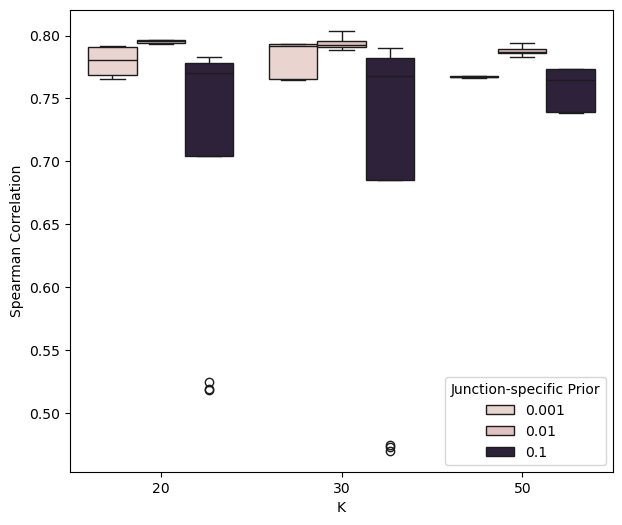

In [13]:
# Make a boxplot of spearman correlation for each K, colored by junction-specific prior
plt.figure(figsize=(7, 6))
sns.boxplot(x='K', y='spearman', data=all_results_df, hue="lr")
plt.xlabel('K')
plt.ylabel('Spearman Correlation')
plt.legend(title='Junction-specific Prior')
plt.show()

In [14]:
all_results_df["Likelihood"] = ""
# if inf then Binomial otherwise if NaN Beta-Binomial
all_results_df["Likelihood"] = all_results_df["input_conc"].apply(lambda x: "Binomial" if x == np.inf else "Beta-Binomial")
all_results_df["Likelihood"].value_counts()

Likelihood
Binomial         48
Beta-Binomial    45
Name: count, dtype: int64

In [15]:
all_results_df = all_results_df[all_results_df["lr"] < 0.1]

In [16]:
all_results_df[["junc_specific_prior", "Likelihood", "K"]].value_counts()

junc_specific_prior  Likelihood     K 
False                Beta-Binomial  20    6
                                    30    6
                                    50    6
                     Binomial       20    6
                                    50    6
True                 Beta-Binomial  30    6
                     Binomial       30    6
                                    20    6
                     Beta-Binomial  20    3
False                Binomial       30    3
True                 Beta-Binomial  50    3
                     Binomial       50    3
Name: count, dtype: int64

In [17]:
all_results_df.columns

Index(['pearson', 'spearman', 'l1_loss', 'rmse', 'num_masked_values', 'K_used',
       'masking_percentage', 'run_name', 'run_idx', 'model_path', 'input_conc',
       'junc_specific_prior', 'delta_fixed', 'K', 'waypoints_use',
       'batch_size', 'num_passes', 'num_epochs_first', 'num_epochs_later',
       'ELBO_num_particles', 'num_samples', 'gamma', 'min_delta', 'lr',
       'patience', 'max_junctions', 'n_waypoints', 'n_pca_components',
       'n_dim_components', 'metacell_size', 'recompute_pca',
       'estimated_total_batches', 'num_inits', 'num_epochs', 'Likelihood'],
      dtype='object')

In [18]:
nmf_results["junc_specific_prior"] = "NA"
nmf_results["Likelihood"] = "NA"
nmf_results["K"] = nmf_results["n_components"]
nmf_results["l1_loss"] = nmf_results["l1_mae"]
nmf_results["spearman"] = nmf_results["spearman_r"]
# make numerical masking percentage, remove % sign and convert to float
nmf_results["masking_percentage"] = nmf_results["mask_percent"].str.rstrip('%').astype(float)
# Append NMF data into all_results_df concat common columns 

In [19]:
# Append NMF data into all_results_df concat common columns 
leaflet = all_results_df[["junc_specific_prior", "Likelihood", "K", "l1_loss", "rmse", "spearman", "masking_percentage"]]
nmf_results = nmf_results[["junc_specific_prior", "Likelihood", "K", "l1_loss", "rmse", "spearman", "masking_percentage"]]

In [20]:
leaflet["model"] = "LeafletFA"
nmf_results["model"] = "NMF"
all_results_df = pd.concat([leaflet, nmf_results])
all_results_df

/scratch/ipykernel_3136180/1416782610.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaflet["model"] = "LeafletFA"


,junc_specific_prior,Likelihood,K,l1_loss,rmse,spearman,masking_percentage,model
0,False,Beta-Binomial,20,0.187592,0.265238,0.765475,75.0,LeafletFA
1,False,Beta-Binomial,20,0.187481,0.265156,0.765611,50.0,LeafletFA
2,False,Beta-Binomial,20,0.187451,0.265124,0.765702,25.0,LeafletFA
0,True,Binomial,30,0.141687,0.237941,0.791526,75.0,LeafletFA
1,True,Binomial,30,0.141613,0.237857,0.791607,50.0,LeafletFA
...,...,...,...,...,...,...,...,...
4,NA,NA,30,0.587947,0.654654,0.235483,50.0,NMF
5,NA,NA,30,0.668602,0.727792,0.234783,75.0,NMF
6,NA,NA,50,0.509783,0.590293,0.237739,25.0,NMF
7,NA,NA,50,0.587365,0.654028,0.237195,50.0,NMF


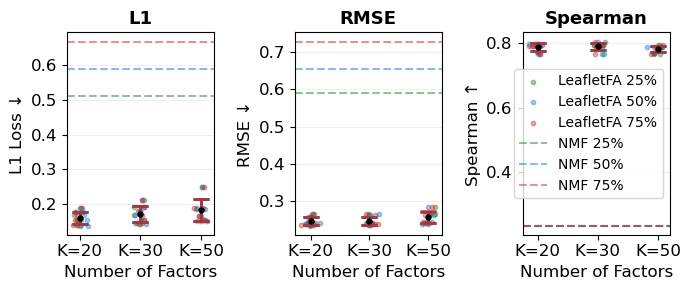

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE2/leaflet_nmf_categorical.pdf


In [23]:
plots_output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE2"

df = all_results_df

# Separate LeafletFA and NMF
leaflet_df = df[df['model'] == 'LeafletFA'].copy()
nmf_df = df[df['model'] == 'NMF'].copy()

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(7, 3))
metrics = ['l1_loss', 'rmse', 'spearman']
titles = ['L1 Loss ↓', 'RMSE ↓', 'Spearman ↑']

# K values as categorical positions
k_values = [20, 30, 50]
k_positions = [0, 1, 2]
mask_colors = {25: '#2E7D32', 50: '#1976D2', 75: '#C62828'}  # Green, Blue, Red

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    
    # Plot LeafletFA data points with jitter
    for mask_pct in [25, 50, 75]:
        subset = leaflet_df[leaflet_df['masking_percentage'] == mask_pct]
        
        for k_idx, k in enumerate(k_values):
            k_data = subset[subset['K'] == k][metric].values
            
            if len(k_data) > 0:
                # Add jitter to x positions
                x_jitter = np.random.normal(0, 0.06, len(k_data))
                x_positions = k_idx + x_jitter
                
                # Plot individual points (smaller)
                # Only add label for the last subplot
                label = f'LeafletFA {mask_pct}%' if (k_idx == 0 and idx == 2) else ""
                ax.scatter(x_positions, k_data, 
                          color=mask_colors[mask_pct],
                          alpha=0.4, s=10,  # Smaller dots
                          label=label)
                
                # Add mean with error bar
                mean_val = k_data.mean()
                std_val = k_data.std()
                
                # Plot mean point - simple black circle
                ax.scatter(k_idx, mean_val, 
                          color='black',
                          s=10, marker='o', 
                          alpha=0.9, zorder=5)
                
                # Add error bar with matching mask color
                ax.errorbar(k_idx, mean_val, yerr=std_val,
                           color=mask_colors[mask_pct], 
                           linewidth=2, capsize=6, capthick=2,
                           alpha=0.8, zorder=4, fmt='none')  # 'none' removes marker from errorbar
    
    # Add NMF baselines as horizontal lines
    for mask_pct in [25, 50, 75]:
        nmf_val = nmf_df[nmf_df['masking_percentage'] == mask_pct][metric].mean()
        # Only add label for the last subplot
        label = f'NMF {mask_pct}%' if idx == 2 else ""
        ax.axhline(nmf_val, 
                  color=mask_colors[mask_pct],
                  linestyle='--',
                  linewidth=1.5,
                  alpha=0.5,
                  label=label)
    
    # Formatting
    ax.set_xticks(k_positions)
    ax.set_xticklabels(['K=20', 'K=30', 'K=50'])
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel('Number of Factors', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(f'{title.split()[0]}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')
    
    # Only add legend to the rightmost plot
    if idx == 2:
        ax.legend(fontsize=10, loc='best')
    
plt.tight_layout()
plt.savefig(f'{plots_output_dir}/leaflet_nmf_categorical.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to {plots_output_dir}/leaflet_nmf_categorical.pdf")